In [1]:
#importing neccessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#read file
df = pd.read_csv("datasets\earthquake_data_tsunami.csv")

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
C:\Users\joshi\AppData\Local\Temp\ipykernel_11948\663632623.py:2: SyntaxWarning: invalid escape sequence '\e'
  df = pd.read_csv("datasets\earthquake_data_tsunami.csv")


Basic Info On Data

In [3]:
#basic info about the dataset
df.head()
df.info()
df['tsunami'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


tsunami
0    478
1    304
Name: count, dtype: int64

Data Cleaning

In [4]:
#isolate core features 
core_features = ['magnitude', 'depth', 'latitude', 'longitude']

#define X and y
X = df[core_features]
y = df['tsunami']

#get ride of any missing values
data = pd.concat([X, y], axis=1).dropna()
X = data[core_features]
y = data['tsunami']

Train-Test Split and Scaling

In [5]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    #varables to control the split of the data
    test_size=0.2,
    random_state=42,
    stratify=y
)
# this controls the scale of the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Reusable Evaluator 

In [6]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    #fit the model and make predictions
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    #print evaluation results
    print(f"\n=== {name} ===")
    print("Confusion matrix:")
    print(confusion_matrix(y_te, y_pred))
    print("\nClassification report:")
    print(classification_report(y_te, y_pred, digits=3))
    #if AUC is an option, calculate and print it
    if y_proba is not None:
        auc = roc_auc_score(y_te, y_proba)
        print(f"ROC-AUC: {auc:.3f}")
    else:
        auc = None
    # return results in a dictionary that will be used later to compare models
    return {
        "model": name,
        "accuracy": (y_pred == y_te).mean(),
        "auc": auc
    }

results = []

Creation of models for testing and training

Model 1 - Logistic Regression

In [7]:
#logistic regression with balanced class weights to handle imbalance
log_reg = LogisticRegression(random_state=42,max_iter=5000)
#evaluate and store results
res_log = evaluate_model("Logistic Regression", log_reg, X_train_scaled, X_test_scaled, y_train, y_test)
#print results
print(f"Logistic Regression - Accuracy: {res_log['accuracy']:.3f}, AUC: {res_log['auc']:.3f}")
results.append(res_log)


=== Logistic Regression ===
Confusion matrix:
[[80 16]
 [49 12]]

Classification report:
              precision    recall  f1-score   support

           0      0.620     0.833     0.711        96
           1      0.429     0.197     0.270        61

    accuracy                          0.586       157
   macro avg      0.524     0.515     0.490       157
weighted avg      0.546     0.586     0.540       157

ROC-AUC: 0.497
Logistic Regression - Accuracy: 0.586, AUC: 0.497


Model 2 - Random Forest

In [8]:
# random forest with balanced class weights to handle imbalance
rf = RandomForestClassifier(n_estimators=800, max_depth=None,random_state=42, class_weight='balanced')

#evaluate and store results
res_rf = evaluate_model("Random Forest", rf, X_train_scaled, X_test_scaled, y_train, y_test)

#print results
print(f"Random Forest - Accuracy: {res_rf['accuracy']:.3f}, AUC: {res_rf['auc']:.3f}")
results.append(res_rf)


=== Random Forest ===
Confusion matrix:
[[74 22]
 [32 29]]

Classification report:
              precision    recall  f1-score   support

           0      0.698     0.771     0.733        96
           1      0.569     0.475     0.518        61

    accuracy                          0.656       157
   macro avg      0.633     0.623     0.625       157
weighted avg      0.648     0.656     0.649       157

ROC-AUC: 0.739
Random Forest - Accuracy: 0.656, AUC: 0.739


Model 3 - Gradient Boosting (unscaled)

In [9]:
# gradient boosting (does not support class weights, but can handle imbalance to some extent)
gb = GradientBoostingClassifier(random_state=42, n_estimators=300, learning_rate=0.05)

# evaluate and store results
res_gb = evaluate_model("Gradient Boosting", gb, X_train_scaled, X_test_scaled, y_train, y_test)

#print results
print(f"Gradient Boosting - Accuracy: {res_gb['accuracy']:.3f}, AUC: {res_gb['auc']:.3f}")
results.append(res_gb)


=== Gradient Boosting ===
Confusion matrix:
[[78 18]
 [29 32]]

Classification report:
              precision    recall  f1-score   support

           0      0.729     0.812     0.768        96
           1      0.640     0.525     0.577        61

    accuracy                          0.701       157
   macro avg      0.684     0.669     0.673       157
weighted avg      0.694     0.701     0.694       157

ROC-AUC: 0.769
Gradient Boosting - Accuracy: 0.701, AUC: 0.769


Charts showing feature importance

In [10]:
core_features = ['magnitude', 'depth', 'latitude', 'longitude']

# after fitting log_reg on scaled data:
log_importance = pd.Series(
    np.abs(log_reg.coef_[0]),
    index=core_features
)
# after fitting rf on scaled data:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=core_features
)
# after fitting gb on scaled data:
gb_importance = pd.Series(
    gb.feature_importances_,
    index=core_features
)
#print feature importances for each model
print("Logistic Regression - Core feature importances:")
print(log_importance.sort_values(ascending=False))

print("Random Forest - Core feature importances:")
print(rf_importance.sort_values(ascending=False))

print("Gradient Boosting - Core feature importances:")
print(gb_importance.sort_values(ascending=False))

Logistic Regression - Core feature importances:
longitude    0.376339
latitude     0.216657
depth        0.096887
magnitude    0.023331
dtype: float64
Random Forest - Core feature importances:
longitude    0.399793
latitude     0.282521
depth        0.198380
magnitude    0.119306
dtype: float64
Gradient Boosting - Core feature importances:
longitude    0.597074
latitude     0.230735
depth        0.118914
magnitude    0.053277
dtype: float64


Simple Plots

C:\Users\joshi\AppData\Local\Temp\ipykernel_11948\1805432536.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


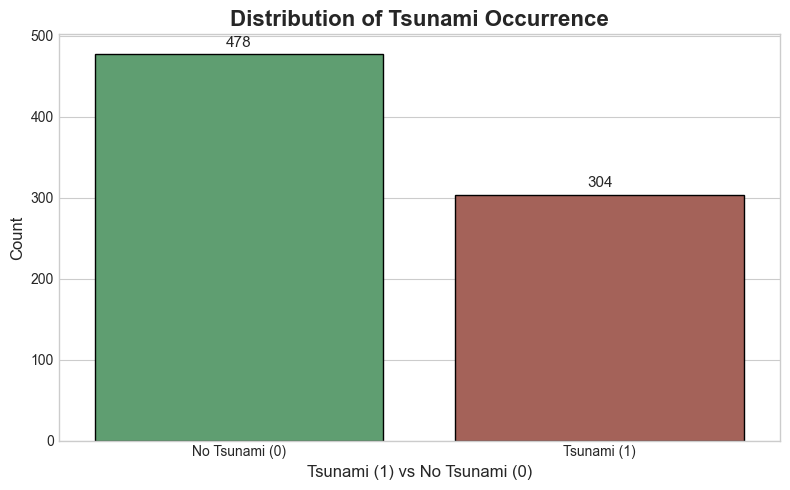

In [11]:
# Count the target values first
tsunami_counts = y.value_counts().reset_index()
tsunami_counts.columns = ["tsunami", "count"]

# making labels 
tsunami_counts["tsunami_label"] = tsunami_counts["tsunami"].map({
    0: "No Tsunami (0)",
    1: "Tsunami (1)"
})
# Create a bar plot to visualize the distribution of tsunami occurrences
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8, 5))
# bar plot with custom colors and edge styling
ax = sns.barplot(
    data=tsunami_counts,
    x="tsunami_label",
    y="count",
    palette=["#55A86DFF", "#B0584C"],
    edgecolor="black",
    linewidth=1
)
# Add titles and labels with custom font sizes and weights
plt.title("Distribution of Tsunami Occurrence", fontsize=16, weight="bold")
plt.xlabel("Tsunami (1) vs No Tsunami (0)", fontsize=12)
plt.ylabel("Count", fontsize=12)
# Add value annotations on top of the bars with custom font size
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height)}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=11
    )
# show the plot
plt.tight_layout()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_11948\1289628241.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


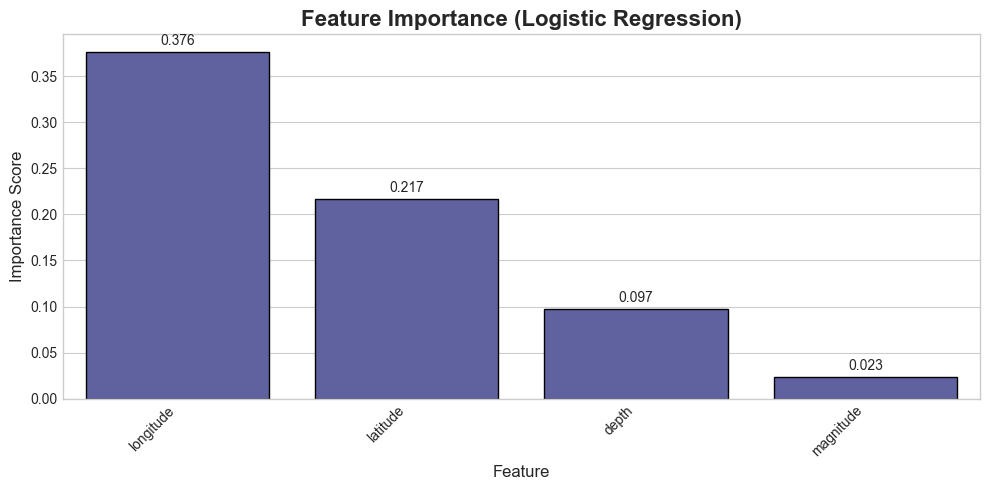

In [12]:
feat_imp = log_importance.sort_values(ascending=False)

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 5))
# bar plot with custom colors and edge styling
ax = sns.barplot(
    x=feat_imp.index,
    y=feat_imp.values,
    palette=["#5559A8FF"] * len(feat_imp),
    edgecolor="black",
    linewidth=1
)
# Add titles and labels with custom font sizes and weights
plt.title(
    "Feature Importance (Logistic Regression)",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)

# Rotate x labels if needed
plt.xticks(rotation=45, ha="right")

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.3f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=10
    )
# Show the plot
plt.tight_layout()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_11948\4063877581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


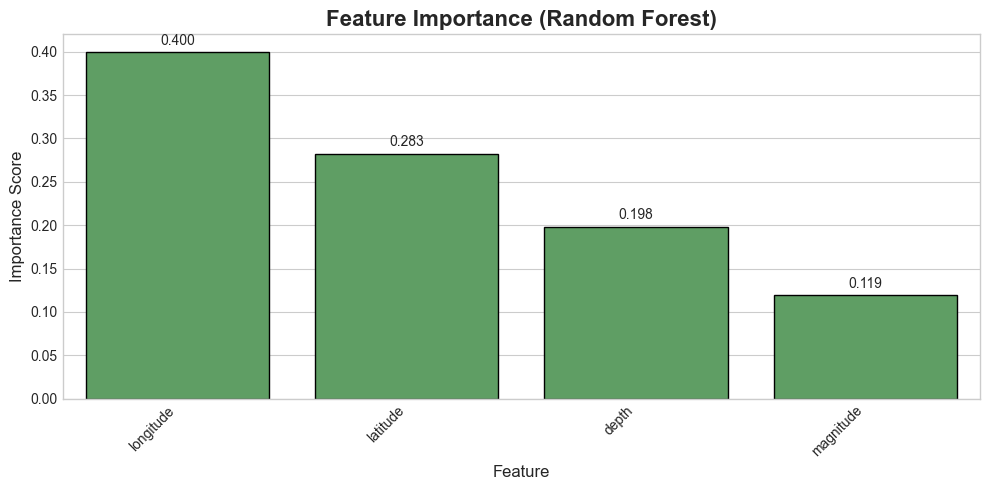

In [13]:

feat_imp = rf_importance.sort_values(ascending=False)

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 5))
# bar plot with custom colors and edge styling
ax = sns.barplot(
    x=feat_imp.index,
    y=feat_imp.values,
    palette=["#55A85BFF"] * len(feat_imp),
    edgecolor="black",
    linewidth=1
)
# Add titles and labels with custom font sizes and weights
plt.title(
    "Feature Importance (Random Forest)",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)

# Rotate x labels if needed
plt.xticks(rotation=45, ha="right")

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.3f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=10
    )

plt.tight_layout()
plt.show()

C:\Users\joshi\AppData\Local\Temp\ipykernel_11948\586261644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


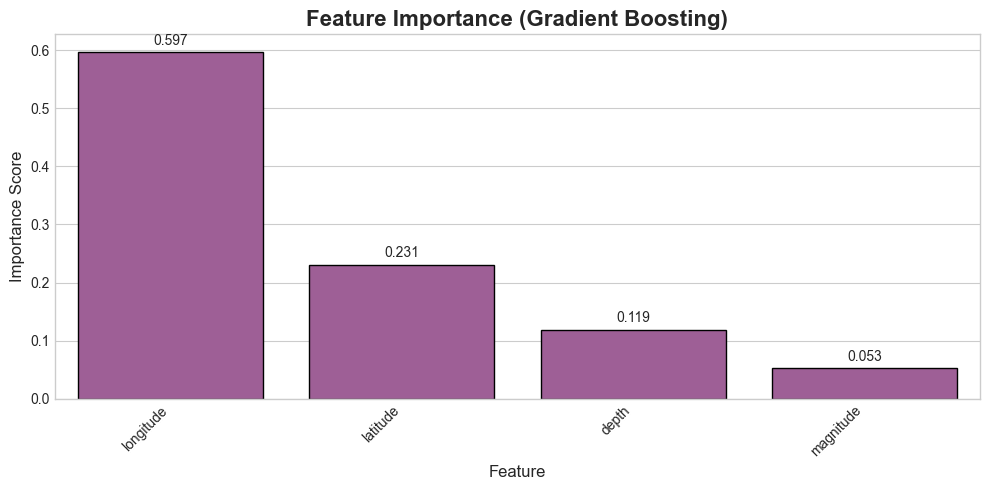

In [14]:

feat_imp = gb_importance.sort_values(ascending=False)
# bar plot with custom colors and edge styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=feat_imp.index,
    y=feat_imp.values,
    palette=["#A8559EFF"] * len(feat_imp),
    edgecolor="black",
    linewidth=1
)
# Add titles and labels with custom font sizes and weights
plt.title(
    "Feature Importance (Gradient Boosting)",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Feature", fontsize=12)
plt.ylabel("Importance Score", fontsize=12)

# Rotate x labels if needed
plt.xticks(rotation=45, ha="right")

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.3f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
        fontsize=10
    )

plt.tight_layout()
plt.show()